<a href="https://colab.research.google.com/github/leejinwoo56/deepfake_detector/blob/main/deepfakedetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CLIP 및 필수 라이브러리 설치
!pip install git+https://github.com/openai/CLIP.git
!pip install facenet-pytorch

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-l67jwtmd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-l67jwtmd
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8a1ef358d2bd7895e2111895845b9b5f88cc9742d6df3ccb850cd5b6b8429f0e
  Stored in directory: /tmp/pip-ephem-wheel-cache-edciaux0/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 13

#Gend 기반 deepfake_detector

[WARN] IMAGE_SIZE=384 is not divisible by 14. Snapping to 378.
DEVICE: cuda | IMAGE_SIZE: 378

[FF++] Build pairs...
FF++ paired orig_ids: 1000

[KODF2] Build participant index...
KODF2 participants with (real&fake): 24
KODF2 Train participants: 24 | Val participants: 0
[KODF2] participants kept=24 | dropped=0 | methods=('dffs1', 'fo1', 'dfl1', 'fsgan1') | use_grok=True


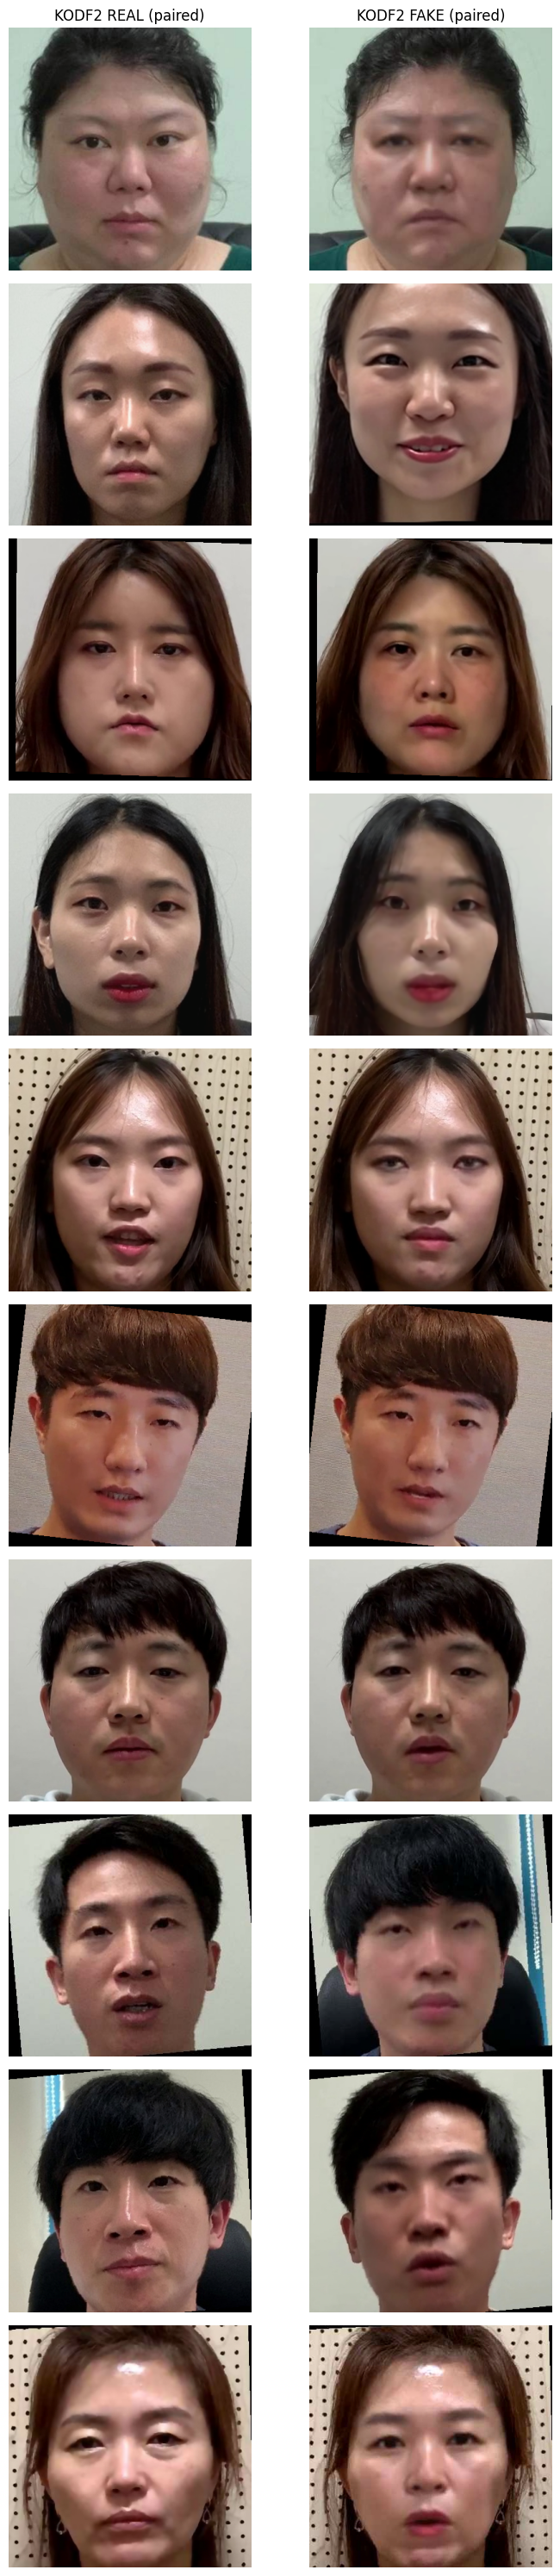


[DFDC] Sampling val videos...
DFDC val videos: 30 | estimated frames: 480 | frames/video: 16

[sample_test] real: img=17, vid=0 | fake: img=24, vid=0

Train total samples: 44000 | steps/epoch: 2750

[Model] Load CLIP & build GenD-CLIP-1024 (+freq) ...
[CLIP] adapted resolution: 224 -> 378 (grid 16 -> 27)
[RESUME] found checkpoint: /content/drive/MyDrive/deepfake/deepfake_ckpt/best_kodf_train_only.pt
visual.width: None | classifier in_features: 1024
[RESUME] model loaded. missing=0 unexpected=0
[RESUME] optimizer loaded.
[RESUME] optimizer state moved to device.
[RESUME] scaler loaded.
[RESUME] start_epoch=7, global_step=9372, best_score=0.732843

[Train] epochs=40 (cycle=10 x 4)
Epoch 7/40 | step 20/2750 | loss=-1.1826 (ce=0.4344, align=1.8025, uni=-3.2526) | lr(LN,Head)=2.51e-05,2.51e-04
Epoch 7/40 | step 40/2750 | loss=-1.1856 (ce=0.3767, align=1.9101, uni=-3.6484) | lr(LN,Head)=2.51e-05,2.51e-04
Epoch 7/40 | step 60/2750 | loss=-1.1877 (ce=0.2821, align=1.8401, uni=-3.5806) | lr(LN

KeyboardInterrupt: 

In [ ]:
import os, glob, re, random, io, warnings
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from collections import defaultdict
import math
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# 시드 고정
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


# 하이퍼파라미터 및 환경 설정
@dataclass
class Config:
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    SEED: int = 42

    IMAGE_SIZE: int = 384
    USE_AMP: bool = True
    PREFER_BF16: bool = True
    NUM_WORKERS: int = 8

    BATCH_SIZE: int = 16

    # sample_test 설정 (이미지, 비디오 혼합 검증)
    USE_SAMPLE_TEST: bool = True
    SAMPLE_TEST_ROOT: str = "/content/drive/MyDrive/deepfake/sample_test"
    SAMPLE_TEST_REAL_DIRNAME: str = "real"
    SAMPLE_TEST_FAKE_DIRNAME: str = "fake"
    SAMPLE_TEST_NUM_FRAMES_PER_VIDEO: int = 32

    # 손실 함수 가중치 및 학습 스케줄러 설정
    ALPHA_ALIGN: float = 0.1
    BETA_UNIFORM: float = 0.5
    USE_FREQ : bool = False
    CYCLE_EPOCHS: int = 10
    NUM_CYCLES: int = 4
    WARMUP_EPOCHS: int = 1

    LN_LR_MAX: float = 3e-5
    LN_LR_MIN: float = 1e-6
    HEAD_LR_MAX: float = 3e-4
    HEAD_LR_MIN: float = 1e-5
    KODF_VAL_VIDEO_RATIO: float = 0.05

    # 주파수(Frequency) 브랜치 설정
    FREQ_POOL: int = 32
    FREQ_GATE_INIT: float = 0.15

    # 데이터 증강(Augmentation) 파라미터
    AFFINE_DEGREES: float = 8.0
    AFFINE_TRANSLATE: Tuple[float, float] = (0.02, 0.02)
    AFFINE_SCALE: Tuple[float, float] = (0.95, 1.05)
    AFFINE_SHEAR: float = 2.0
    JPEG_QUALITY_RANGE: Tuple[int, int] = (30, 95)

    # FF++ 데이터셋 설정
    USE_FFPP: bool = True
    FFPP_ROOT: str = "/content/drive/MyDrive/deepfake/processed_data_retina_align"
    FFPP_REAL_CAT: str = "original"
    FFPP_FAKE_CATS: Tuple[str, ...] = ("Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures", "FaceShifter")
    FFPP_TRAIN_SAMPLES_PER_OID: int = 32

    FFPP_USE_VAL_SPLIT: bool = False
    FFPP_VAL_RATIO: float = 0.2

    # KODF 데이터셋 설정
    USE_KODF: bool = False
    KODF_ROOT: str = "/content/drive/MyDrive/deepfake/kodf"
    KODF_REAL_SUBDIR: str = "real"
    KODF_FAKE_SUBDIR: str = "fake"
    KODF_METHODS: Tuple[str, ...] = ("fsgan", "fo", "dfl", "dffs")

    KODF_VAL_NUM_PARTICIPANTS: int = 0
    KODF_TRAIN_SAMPLES_PER_PID: int = 200
    VAL_MAX_FRAMES_PER_VIDEO: int = 16

    # KODF2 데이터셋 설정
    USE_KODF2: bool = True
    KODF2_ROOT: str = "/content/drive/MyDrive/deepfake/kodf2"
    KODF2_REAL_SUBDIR: str = "real_processed"
    KODF2_FAKE_SUBDIR: str = "fake_processed"

    KODF2_METHODS: Tuple[str, ...] = ("dffs1", "fo1", "dfl1", "fsgan1")
    KODF2_USE_METHODS: Tuple[str, ...] =("dffs1", "fo1", "dfl1", "fsgan1")

    # KODF2 grok 설정
    KODF2_USE_GROK: bool = True
    KODF2_GROK_SUBDIR: str = "fake_grok_processed"
    KODF2_GROK_PREFER_REAL_SUFFIX: int = 1

    KODF2_VAL_NUM_PARTICIPANTS: int = 0
    KODF2_TRAIN_SAMPLES_PER_PID: int = 500

    # DFDC 데이터셋 설정
    USE_DFDC_VAL: bool = True
    DFDC_ROOT: str = "/content/drive/MyDrive/deepfake/dfdc"
    DFDC_REAL_DIRNAME: str = "Real"
    DFDC_FAKE_DIRNAME: str = "Fake"

    DFDC_NUM_FRAMES_PER_VIDEO: int = 16
    DFDC_VAL_FRAME_BUDGET: int = 500
    DFDC_BALANCE_REAL_FAKE: bool = True
    DFDC_USE_ALIGN: bool = False

    # 모델 체크포인트 저장 및 불러오기 설정
    CLIP_NAME: str = "ViT-L/14"
    BEST_CKPT_PATH: str = "/content/drive/MyDrive/deepfake/deepfake_ckpt/best_kodf_train_only.pt"
    LAST_CKPT_PATH: str = "/content/drive/MyDrive/deepfake/deepfake_ckpt/last_kodf_train_only.pt"
    RESUME_WEIGHTS: bool = True
    RESUME_PATH: str = "/content/drive/MyDrive/deepfake/deepfake_ckpt/best_kodf_train_only.pt"

cfg = Config()
seed_everything(cfg.SEED)
os.makedirs(os.path.dirname(cfg.BEST_CKPT_PATH), exist_ok=True)

# ViT 입력 해상도 패치 배수 맞춤
CLIP_PATCH = 14
if cfg.IMAGE_SIZE % CLIP_PATCH != 0:
    snapped = int(round(cfg.IMAGE_SIZE / CLIP_PATCH) * CLIP_PATCH)
    print(f"[WARN] IMAGE_SIZE={cfg.IMAGE_SIZE} is not divisible by {CLIP_PATCH}. Snapping to {snapped}.")
    cfg.IMAGE_SIZE = snapped

print("DEVICE:", cfg.DEVICE, "| IMAGE_SIZE:", cfg.IMAGE_SIZE)


# 파일 및 경로 처리 유틸리티
IMG_EXTS = (".png", ".jpg", ".jpeg", ".jfif")

def has_any_image(dir_path: str) -> bool:
    if not os.path.isdir(dir_path):
        return False
    try:
        for e in os.scandir(dir_path):
            if e.is_file():
                n = e.name.lower()
                if n.endswith(IMG_EXTS):
                    return True
        return False
    except Exception:
        return False


def _last_int_from_name(name: str) -> Optional[int]:
    m = re.findall(r"(\d+)", name)
    if not m:
        return None
    try:
        return int(m[-1])
    except:
        return None


def list_frames(dir_path: str) -> List[str]:
    if not os.path.isdir(dir_path):
        return []
    tmp = []
    try:
        for e in os.scandir(dir_path):
            if e.is_file():
                n = e.name.lower()
                if n.endswith(IMG_EXTS):
                    k = _last_int_from_name(e.name)
                    tmp.append(((10**12) if k is None else k, e.path))
    except Exception:
        return []
    tmp.sort(key=lambda x: (x[0], x[1]))
    return [p for _, p in tmp]


def list_video_dirs(root: str) -> List[str]:
    if not os.path.exists(root):
        return []
    out = []
    for x in os.listdir(root):
        p = os.path.join(root, x)
        if os.path.isdir(p):
            out.append(p)
    return sorted(out)


def extract_orig_id_from_name(name: str) -> str:
    m = re.match(r"^(\d+)", name)
    if m:
        return m.group(1)
    return name.split("_")[0]


def uniform_sample_indices(total: int, num: int) -> List[int]:
    if total <= 0:
        return []
    if num <= 0 or num >= total:
        return list(range(total))
    return np.linspace(0, total - 1, num, dtype=int).tolist()


def safe_auc(y_true: List[int], y_score: List[float]) -> float:
    try:
        return float(roc_auc_score(np.array(y_true), np.array(y_score)))
    except Exception:
        return 0.5


def lr_at_step_in_cycle(step_in_cycle: int, cycle_steps: int, warmup_steps: int,
                        lr_min: float, lr_max: float) -> float:
    if step_in_cycle < warmup_steps:
        t = (step_in_cycle + 1) / max(1, warmup_steps)
        return lr_min + (lr_max - lr_min) * t
    t = (step_in_cycle - warmup_steps) / max(1, (cycle_steps - warmup_steps))
    return lr_min + (lr_max - lr_min) * 0.5 * (1.0 + math.cos(math.pi * t))


# FF++ 데이터 페어 생성
def build_ffpp_pairs(cfg: Config):
    real_by_oid: Dict[str, str] = {}
    fakes_by_oid: Dict[str, List[str]] = defaultdict(list)

    real_root = os.path.join(cfg.FFPP_ROOT, cfg.FFPP_REAL_CAT)
    for vd in list_video_dirs(real_root):
        oid = extract_orig_id_from_name(os.path.basename(vd))
        real_by_oid[oid] = vd

    for cat in cfg.FFPP_FAKE_CATS:
        fake_root = os.path.join(cfg.FFPP_ROOT, cat)
        for vd in list_video_dirs(fake_root):
            oid = extract_orig_id_from_name(os.path.basename(vd))
            fakes_by_oid[oid].append(vd)

    oids = sorted(set(real_by_oid.keys()) & set(fakes_by_oid.keys()))
    pairs = [(oid, real_by_oid[oid], fakes_by_oid[oid]) for oid in oids]
    return pairs


# KODF 인덱스 빌드
def build_kodf_index(cfg: Config):
    real_root = os.path.join(cfg.KODF_ROOT, cfg.KODF_REAL_SUBDIR)
    fake_root = os.path.join(cfg.KODF_ROOT, cfg.KODF_FAKE_SUBDIR)

    real_by_pid: Dict[str, List[str]] = defaultdict(list)
    fake_by_pid: Dict[str, List[str]] = defaultdict(list)

    if os.path.exists(real_root):
        for date_ent in os.scandir(real_root):
            if not date_ent.is_dir():
                continue
            date = date_ent.name
            print("[KODF][real] date:", date)

            for pid_ent in os.scandir(date_ent.path):
                if not pid_ent.is_dir():
                    continue
                pid = pid_ent.name

                for v_ent in os.scandir(pid_ent.path):
                    if not v_ent.is_dir():
                        continue
                    vpath = v_ent.path
                    if has_any_image(vpath):
                        real_by_pid[pid].append(vpath)

    if os.path.exists(fake_root):
        for date_ent in os.scandir(fake_root):
            if not date_ent.is_dir():
                continue
            date = date_ent.name
            print("[KODF][fake] date:", date)

            for pid_ent in os.scandir(date_ent.path):
                if not pid_ent.is_dir():
                    continue
                pid = pid_ent.name
                pidp = pid_ent.path

                methods = cfg.KODF_METHODS if cfg.KODF_METHODS else []
                if methods:
                    method_iter = methods
                else:
                    method_iter = [m.name for m in os.scandir(pidp) if m.is_dir()]

                for method in method_iter:
                    mp = os.path.join(pidp, method)
                    if not os.path.isdir(mp):
                        continue

                    for out_ent in os.scandir(mp):
                        if not out_ent.is_dir():
                            continue
                        vpath = out_ent.path
                        if has_any_image(vpath):
                            fake_by_pid[pid].append(vpath)

    pids = sorted(set(real_by_pid.keys()) & set(fake_by_pid.keys()))
    index = []
    for pid in pids:
        r = real_by_pid[pid]
        f = fake_by_pid[pid]
        if len(r) == 0 or len(f) == 0:
            continue
        index.append((pid, sorted(r), sorted(f)))
    return index


# KODF2 인덱스 빌드 (grok 포함)
def _collect_video_like_dirs(path: str) -> List[str]:
    if not os.path.isdir(path):
        return []
    if has_any_image(path):
        return [path]
    out = []
    try:
        for e in os.scandir(path):
            if e.is_dir() and has_any_image(e.path):
                out.append(e.path)
    except Exception:
        return []
    return sorted(out)

def build_kodf2_index(cfg: Config):
    real_root = os.path.join(cfg.KODF2_ROOT, cfg.KODF2_REAL_SUBDIR)
    fake_root = os.path.join(cfg.KODF2_ROOT, cfg.KODF2_FAKE_SUBDIR)
    grok_root = os.path.join(cfg.KODF2_ROOT, cfg.KODF2_GROK_SUBDIR)

    real_by_pid: Dict[str, List[str]] = defaultdict(list)
    fake_by_pid: Dict[str, List[str]] = defaultdict(list)

    if os.path.isdir(real_root):
        for pid_ent in os.scandir(real_root):
            if not pid_ent.is_dir():
                continue
            pid = pid_ent.name
            rdirs = _collect_video_like_dirs(pid_ent.path)
            if rdirs:
                real_by_pid[pid].extend(rdirs)

    if os.path.isdir(fake_root):
        methods = list(cfg.KODF2_USE_METHODS) if cfg.KODF2_USE_METHODS else []
        if not methods:
            methods = [m.name for m in os.scandir(fake_root) if m.is_dir()]

        for method in methods:
            mp = os.path.join(fake_root, method)
            if not os.path.isdir(mp):
                continue
            for pid_ent in os.scandir(mp):
                if not pid_ent.is_dir():
                    continue
                pid = pid_ent.name
                fdirs = _collect_video_like_dirs(pid_ent.path)
                if fdirs:
                    fake_by_pid[pid].extend(fdirs)
    else:
        print("[KODF2] fake_processed root not found:", fake_root)

    if cfg.KODF2_USE_GROK:
        if os.path.isdir(grok_root):
            for pid_ent in os.scandir(grok_root):
                if not pid_ent.is_dir():
                    continue
                pid = pid_ent.name
                if has_any_image(pid_ent.path):
                    fake_by_pid[pid].append(pid_ent.path)
        else:
            print("[KODF2] fake_grok_processed root not found:", grok_root)

    pids = sorted(set(real_by_pid.keys()) & set(fake_by_pid.keys()))
    index = []

    for pid in pids:
        rdirs = [d for d in real_by_pid[pid] if has_any_image(d)]
        fdirs = [d for d in fake_by_pid[pid] if has_any_image(d)]
        if not rdirs or not fdirs:
            continue

        real_ids = set()
        for rd in rdirs:
            rid = _last_int_from_name(os.path.basename(rd))
            if rid is not None:
                real_ids.add(rid)

        fdirs_ok = []
        for fd in fdirs:
            is_grok = (os.sep + cfg.KODF2_GROK_SUBDIR + os.sep) in (fd + os.sep)
            if is_grok:
                fdirs_ok.append(fd)
                continue

            fid = _last_int_from_name(os.path.basename(fd))
            if fid is None:
                fdirs_ok.append(fd)
            else:
                if (len(real_ids) == 0) or (fid in real_ids):
                    fdirs_ok.append(fd)

        if not fdirs_ok:
            continue

        index.append((pid, sorted(rdirs), sorted(fdirs_ok)))

    return index


# 이미지 처리 및 Augmentation (페어 증강)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

def resize_if_needed_pil(img: Image.Image, size: int) -> Image.Image:
    if img.size[0] != size or img.size[1] != size:
        return img.resize((size, size), resample=Image.BICUBIC)
    return img

def val_tf(img: Image.Image):
    img = resize_if_needed_pil(img, cfg.IMAGE_SIZE)
    x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor(CLIP_MEAN).view(3,1,1)
    std  = torch.tensor(CLIP_STD).view(3,1,1)
    return (x - mean) / std

def jpeg_compress_pil(img: Image.Image, quality: int) -> Image.Image:
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=int(quality))
    buf.seek(0)
    out = Image.open(buf).convert("RGB")
    return out

def skin_smooth_pil(img: Image.Image, strength: float = 0.7) -> Image.Image:
    try:
        import cv2
        arr = np.array(img).astype(np.uint8)
        bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        d = 7
        sigmaColor = int(30 + 60 * strength)
        sigmaSpace = int(10 + 30 * strength)
        smooth = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)
        alpha = float(0.55 + 0.35 * strength)
        out = cv2.addWeighted(smooth, alpha, bgr, 1.0 - alpha, 0)
        rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
        return Image.fromarray(rgb)
    except Exception:
        from PIL import ImageFilter
        return img.filter(ImageFilter.SMOOTH_MORE)

class PairedAugment:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.flip_p = 0.5
        self.jitter_p = 0.5
        self.blur_p = 0.0
        self.jpeg_p = 0.5
        self.affine_p = 0.5
        self.skin_smooth_p = 0.35
        self.skin_strength_rng = (0.4, 0.95)
        self.jpeg_qmin, self.jpeg_qmax = cfg.JPEG_QUALITY_RANGE

    def __call__(self, img_r: Image.Image, img_f: Image.Image):
        img_r = resize_if_needed_pil(img_r, self.cfg.IMAGE_SIZE)
        img_f = resize_if_needed_pil(img_f, self.cfg.IMAGE_SIZE)

        if random.random() < self.flip_p:
            img_r = img_r.transpose(Image.FLIP_LEFT_RIGHT)
            img_f = img_f.transpose(Image.FLIP_LEFT_RIGHT)

        if random.random() < self.jitter_p:
            b = random.uniform(0.9, 1.1)
            c = random.uniform(0.9, 1.1)
            s = random.uniform(0.9, 1.1)
            from PIL import ImageEnhance
            img_r = ImageEnhance.Brightness(img_r).enhance(b)
            img_f = ImageEnhance.Brightness(img_f).enhance(b)
            img_r = ImageEnhance.Contrast(img_r).enhance(c)
            img_f = ImageEnhance.Contrast(img_f).enhance(c)
            img_r = ImageEnhance.Color(img_r).enhance(s)
            img_f = ImageEnhance.Color(img_f).enhance(s)

        if random.random() < self.blur_p:
            from PIL import ImageFilter
            radius = random.uniform(0.1, 1.2)
            img_r = img_r.filter(ImageFilter.GaussianBlur(radius))
            img_f = img_f.filter(ImageFilter.GaussianBlur(radius))

        if random.random() < self.affine_p:
            angle = random.uniform(-self.cfg.AFFINE_DEGREES, self.cfg.AFFINE_DEGREES)
            max_dx = self.cfg.AFFINE_TRANSLATE[0] * self.cfg.IMAGE_SIZE
            max_dy = self.cfg.AFFINE_TRANSLATE[1] * self.cfg.IMAGE_SIZE
            translate = (random.uniform(-max_dx, max_dx), random.uniform(-max_dy, max_dy))
            scale = random.uniform(self.cfg.AFFINE_SCALE[0], self.cfg.AFFINE_SCALE[1])
            shear = random.uniform(-self.cfg.AFFINE_SHEAR, self.cfg.AFFINE_SHEAR)

            img_r = TF.affine(img_r, angle=angle, translate=translate, scale=scale, shear=[shear, 0.0])
            img_f = TF.affine(img_f, angle=angle, translate=translate, scale=scale, shear=[shear, 0.0])

        if random.random() < self.jpeg_p:
            q = random.randint(self.jpeg_qmin, self.jpeg_qmax)
            img_r = jpeg_compress_pil(img_r, q)
            img_f = jpeg_compress_pil(img_f, q)

        if random.random() < self.skin_smooth_p:
            strength = random.uniform(*self.skin_strength_rng)
            mode = random.random()
            if mode < 0.33:
                img_r = skin_smooth_pil(img_r, strength=strength)
            elif mode < 0.66:
                img_f = skin_smooth_pil(img_f, strength=strength)
            else:
                img_r = skin_smooth_pil(img_r, strength=strength)
                img_f = skin_smooth_pil(img_f, strength=strength)

        x_r = val_tf(img_r)
        x_f = val_tf(img_f)
        return x_r, x_f


# 데이터셋 클래스 (FF++, KODF, KODF2)
class PairedFFPPDataset(Dataset):
    def __init__(self, pairs, samples_per_oid: int, deterministic: bool, pair_transform: Optional[PairedAugment]):
        self.samples_per_oid = samples_per_oid
        self.deterministic = deterministic
        self.pair_transform = pair_transform

        keep = []
        self.real_frames = []
        self.fake_frames_list = []

        for oid, real_dir, fake_dirs in pairs:
            rfs = list_frames(real_dir)
            ffs_list = [list_frames(fd) for fd in fake_dirs]
            ffs_list = [x for x in ffs_list if len(x) > 0]
            if len(rfs) == 0 or len(ffs_list) == 0:
                continue
            keep.append((oid, real_dir, fake_dirs))
            self.real_frames.append(rfs)
            self.fake_frames_list.append(ffs_list)

        self.pairs = keep

    def __len__(self):
        return len(self.pairs) * self.samples_per_oid

    def __getitem__(self, idx):
        n_oid = len(self.pairs)
        oid_idx = idx % n_oid
        k = idx // n_oid

        oid, real_dir, fake_dirs = self.pairs[oid_idx]
        rfs = self.real_frames[oid_idx]
        ffs = random.choice(self.fake_frames_list[oid_idx])

        n = min(len(rfs), len(ffs))
        if self.deterministic:
            grid = uniform_sample_indices(n, self.samples_per_oid)
            fi = int(grid[min(k, len(grid)-1)])
        else:
            fi = random.randint(0, n - 1)

        img_r = Image.open(rfs[fi]).convert("RGB")
        img_f = Image.open(ffs[fi]).convert("RGB")

        if (not self.deterministic) and (self.pair_transform is not None):
            x_r, x_f = self.pair_transform(img_r, img_f)
        else:
            x_r = val_tf(img_r)
            x_f = val_tf(img_f)

        return x_r, x_f


def extract_numeric_suffix(s: str) -> Optional[str]:
    m = re.findall(r"(\d+)", s)
    if not m:
        return None
    return m[-1]

def extract_suffix_int(s: str) -> Optional[int]:
    tag = extract_numeric_suffix(s)
    if tag is None:
        return None
    try:
        return int(tag)
    except:
        return None

class PairedKODFDataset(Dataset):
    def __init__(
        self,
        pid_index,
        samples_per_pid: int,
        deterministic: bool,
        pair_transform: Optional[PairedAugment],
        max_fake_id: Optional[int] = 150,
    ):
        self.samples_per_pid = samples_per_pid
        self.deterministic = deterministic
        self.pair_transform = pair_transform
        self.max_fake_id = max_fake_id

        self.pids: List[str] = []
        self.real_dirs: List[List[str]] = []
        self.fake_dirs: List[List[str]] = []
        self.real_suffix_maps: List[Dict[int, List[str]]] = []

        self._frames_cache: Dict[str, List[str]] = {}

        dropped_no_real = 0
        dropped_no_fake = 0
        dropped_no_fake_under_max = 0

        for pid, rdirs, fdirs in pid_index:
            rdirs = [d for d in rdirs if has_any_image(d)]
            fdirs = [d for d in fdirs if has_any_image(d)]

            if len(rdirs) == 0:
                dropped_no_real += 1
                continue
            if len(fdirs) == 0:
                dropped_no_fake += 1
                continue

            if self.max_fake_id is not None:
                fdirs_ok = []
                for d in fdirs:
                    tag_i = extract_suffix_int(os.path.basename(d)) or extract_suffix_int(d)
                    if tag_i is not None and tag_i <= self.max_fake_id:
                        fdirs_ok.append(d)
                fdirs = fdirs_ok

            if len(fdirs) == 0:
                dropped_no_fake_under_max += 1
                continue

            rmap = defaultdict(list)
            for rd in rdirs:
                rt_i = extract_suffix_int(os.path.basename(rd)) or extract_suffix_int(rd)
                if rt_i is not None:
                    rmap[rt_i].append(rd)

            self.pids.append(pid)
            self.real_dirs.append(sorted(rdirs))
            self.fake_dirs.append(sorted(fdirs))
            self.real_suffix_maps.append(dict(rmap))

        if len(self.pids) == 0:
            raise RuntimeError(
                f"[KODF] After filtering, no participants left. "
                f"(dropped_no_real={dropped_no_real}, "
                f"dropped_no_fake={dropped_no_fake}, "
                f"dropped_no_fake_under_max={dropped_no_fake_under_max}, "
                f"max_fake_id={self.max_fake_id})"
            )

        print(
            f"[KODF] participants kept={len(self.pids)} | "
            f"dropped_no_real={dropped_no_real}, dropped_no_fake={dropped_no_fake}, "
            f"dropped_no_fake_under_max={dropped_no_fake_under_max} | "
            f"max_fake_id={self.max_fake_id}"
        )

    def __len__(self):
        return len(self.pids) * self.samples_per_pid

    def _get_frames(self, vdir: str) -> List[str]:
        if vdir in self._frames_cache:
            return self._frames_cache[vdir]
        fs = list_frames(vdir)
        self._frames_cache[vdir] = fs
        return fs

    def __getitem__(self, idx):
        n_pid = len(self.pids)
        pid_idx = idx % n_pid
        k = idx // n_pid

        rdirs = self.real_dirs[pid_idx]
        fdirs = self.fake_dirs[pid_idx]
        rmap = self.real_suffix_maps[pid_idx]

        fake_dir = random.choice(fdirs)
        fake_tag_i = extract_suffix_int(os.path.basename(fake_dir)) or extract_suffix_int(fake_dir)

        real_dir = None
        if fake_tag_i is not None and fake_tag_i in rmap and len(rmap[fake_tag_i]) > 0:
            real_dir = random.choice(rmap[fake_tag_i])
        if real_dir is None:
            real_dir = random.choice(rdirs)

        rfs = self._get_frames(real_dir)
        ffs = self._get_frames(fake_dir)

        n = min(len(rfs), len(ffs))
        if n <= 0:
            img_r = Image.open(rfs[0]).convert("RGB")
            img_f = Image.open(ffs[0]).convert("RGB")
            return val_tf(img_r), val_tf(img_f)

        if self.deterministic:
            grid = uniform_sample_indices(n, self.samples_per_pid)
            fi = int(grid[min(k, len(grid) - 1)])
        else:
            fi = random.randint(0, n - 1)

        img_r = Image.open(rfs[fi]).convert("RGB")
        img_f = Image.open(ffs[fi]).convert("RGB")

        if (not self.deterministic) and (self.pair_transform is not None):
            x_r, x_f = self.pair_transform(img_r, img_f)
        else:
            x_r = val_tf(img_r)
            x_f = val_tf(img_f)

        return x_r, x_f

class PairedKODF2FlexibleDataset(Dataset):
    def __init__(
        self,
        pid_index,
        samples_per_pid: int,
        deterministic: bool,
        pair_transform: Optional[PairedAugment],
        grok_token: str,
        grok_prefer_real_suffix: int,
    ):
        self.samples_per_pid = samples_per_pid
        self.deterministic = deterministic
        self.pair_transform = pair_transform
        self.grok_token = grok_token
        self.grok_prefer_real_suffix = grok_prefer_real_suffix

        self.pids: List[str] = []
        self.real_dirs: List[List[str]] = []
        self.fake_dirs: List[List[str]] = []

        self._frame_map_cache: Dict[str, Dict[int, str]] = {}
        self._frame_list_cache: Dict[str, List[str]] = {}

        dropped = 0
        for pid, rdirs, fdirs in pid_index:
            rdirs = [d for d in rdirs if has_any_image(d)]
            fdirs = [d for d in fdirs if has_any_image(d)]
            if not rdirs or not fdirs:
                dropped += 1
                continue
            self.pids.append(pid)
            self.real_dirs.append(sorted(rdirs))
            self.fake_dirs.append(sorted(fdirs))

        if len(self.pids) == 0:
            raise RuntimeError(f"[KODF2] After filtering, no participants left (dropped={dropped}).")

        print(f"[KODF2] participants kept={len(self.pids)} | dropped={dropped} | methods={cfg.KODF2_USE_METHODS} | use_grok={cfg.KODF2_USE_GROK}")

    def __len__(self):
        return len(self.pids) * self.samples_per_pid

    def _get_frame_list(self, vdir: str) -> List[str]:
        if vdir in self._frame_list_cache:
            return self._frame_list_cache[vdir]
        fs = list_frames(vdir)
        self._frame_list_cache[vdir] = fs
        return fs

    def _get_frame_map(self, vdir: str) -> Dict[int, str]:
        if vdir in self._frame_map_cache:
            return self._frame_map_cache[vdir]
        fs = self._get_frame_list(vdir)
        mp: Dict[int, str] = {}
        for p in fs:
            k = _last_int_from_name(os.path.basename(p))
            if k is None:
                continue
            if k not in mp:
                mp[k] = p
        self._frame_map_cache[vdir] = mp
        return mp

    def _choose_real_dir(self, rdirs: List[str], fake_dir: str) -> str:
        is_grok = (os.sep + self.grok_token + os.sep) in (fake_dir + os.sep)
        if is_grok and self.grok_prefer_real_suffix is not None:
            target = int(self.grok_prefer_real_suffix)
            cands = []
            for rd in rdirs:
                rid = _last_int_from_name(os.path.basename(rd))
                if rid == target:
                    cands.append(rd)
            if cands:
                return random.choice(cands)
            return random.choice(rdirs)

        fid = _last_int_from_name(os.path.basename(fake_dir))
        if fid is None:
            return random.choice(rdirs)

        cands = []
        for rd in rdirs:
            rid = _last_int_from_name(os.path.basename(rd))
            if rid == fid:
                cands.append(rd)
        if cands:
            return random.choice(cands)
        return random.choice(rdirs)

    def __getitem__(self, idx):
        n_pid = len(self.pids)
        pid_idx = idx % n_pid
        k = idx // n_pid

        rdirs = self.real_dirs[pid_idx]
        fdirs = self.fake_dirs[pid_idx]

        fake_dir = random.choice(fdirs)
        real_dir = self._choose_real_dir(rdirs, fake_dir)

        rmap = self._get_frame_map(real_dir)
        fmap = self._get_frame_map(fake_dir)

        common = sorted(set(rmap.keys()) & set(fmap.keys()))
        if common:
            if self.deterministic:
                grid = uniform_sample_indices(len(common), self.samples_per_pid)
                ci = int(grid[min(k, len(grid) - 1)])
                frame_id = common[ci]
            else:
                frame_id = random.choice(common)
            rp = rmap[frame_id]
            fp = fmap[frame_id]
        else:
            rfs = self._get_frame_list(real_dir)
            ffs = self._get_frame_list(fake_dir)
            n = min(len(rfs), len(ffs))
            if n <= 0:
                rp = rfs[0]
                fp = ffs[0]
            else:
                if self.deterministic:
                    grid = uniform_sample_indices(n, self.samples_per_pid)
                    fi = int(grid[min(k, len(grid) - 1)])
                else:
                    fi = random.randint(0, n - 1)
                rp = rfs[fi]
                fp = ffs[fi]

        img_r = Image.open(rp).convert("RGB")
        img_f = Image.open(fp).convert("RGB")

        if (not self.deterministic) and (self.pair_transform is not None):
            x_r, x_f = self.pair_transform(img_r, img_f)
        else:
            x_r = val_tf(img_r)
            x_f = val_tf(img_f)

        return x_r, x_f


# 모델 구성 (GenD-CLIP 및 Frequency Branch)
import clip
import torch.nn.functional as F

def is_layernorm(m: nn.Module) -> bool:
    return isinstance(m, nn.LayerNorm) or ("layernorm" in m.__class__.__name__.lower())

def adapt_clip_resolution(clip_model: nn.Module, new_res: int):
    visual = clip_model.visual
    if not (hasattr(visual, "positional_embedding") and hasattr(visual, "conv1")):
        print("[WARN] visual has no positional_embedding/conv1. Skip adapt.")
        return clip_model

    patch = visual.conv1.kernel_size[0]
    if new_res % patch != 0:
        raise ValueError(f"new_res={new_res} must be divisible by patch={patch}")

    pe = visual.positional_embedding
    n_old = pe.shape[0] - 1
    g_old = int(math.sqrt(n_old))
    g_new = new_res // patch

    if g_old * g_old != n_old:
        print("[WARN] unexpected positional_embedding shape. Skip adapt.")
        return clip_model

    cls_tok = pe[:1]
    patch_tok = pe[1:]
    dim = patch_tok.shape[1]

    patch_tok = patch_tok.float().reshape(g_old, g_old, dim).permute(2, 0, 1).unsqueeze(0)
    patch_tok = F.interpolate(patch_tok, size=(g_new, g_new), mode="bicubic", align_corners=False)
    patch_tok = patch_tok.squeeze(0).permute(1, 2, 0).reshape(g_new * g_new, dim)

    new_pe = torch.cat([cls_tok.float(), patch_tok], dim=0).to(pe.device, dtype=pe.dtype)
    visual.positional_embedding = nn.Parameter(new_pe)

    if hasattr(visual, "input_resolution"):
        visual.input_resolution = new_res

    print(f"[CLIP] adapted resolution: {g_old*patch} -> {new_res} (grid {g_old} -> {g_new})")
    return clip_model

class GenD_CLIP_1024(nn.Module):
    def __init__(self, clip_backbone, freq_pool=32, freq_gate_init=0.15, use_freq=True):
        super().__init__()
        self.clip = clip_backbone
        self.width = int(getattr(self.clip.visual, "width", 1024))
        self.use_freq = bool(use_freq)
        self.freq_pool = int(freq_pool)
        if self.use_freq:
            self.freq_proj = nn.Sequential(
                nn.LayerNorm(self.freq_pool * self.freq_pool),
                nn.Linear(self.freq_pool * self.freq_pool, self.width),
                nn.GELU(),
                nn.Linear(self.width, self.width),
            )
            init = float(freq_gate_init)
            init = min(max(init, 1e-4), 1.0 - 1e-4)
            self.freq_gate_logit = nn.Parameter(torch.tensor(math.log(init / (1.0 - init)), dtype=torch.float32))
        else:
            self.freq_proj = None
            self.freq_gate_logit = None

        self.classifier = nn.Linear(self.width, 2)

        for p in self.clip.parameters():
            p.requires_grad = False

        for m in self.clip.visual.modules():
            if is_layernorm(m):
                for p in m.parameters():
                    p.requires_grad = True

        for p in self.classifier.parameters():
            p.requires_grad = True
        if self.use_freq:
            for p in self.freq_proj.parameters():
                p.requires_grad = True
            self.freq_gate_logit.requires_grad = True

        self.register_buffer("clip_mean", torch.tensor(CLIP_MEAN).view(1,3,1,1), persistent=False)
        self.register_buffer("clip_std",  torch.tensor(CLIP_STD).view(1,3,1,1), persistent=False)

        self._preproj = None
        if hasattr(self.clip.visual, "ln_post"):
            self.clip.visual.ln_post.register_forward_hook(self._hook_ln_post)
        else:
            raise RuntimeError("CLIP visual has no ln_post; cannot capture pre-proj CLS.")

    def _hook_ln_post(self, module, inp, out):
        self._preproj = out

    def _freq_features(self, x_norm: torch.Tensor) -> torch.Tensor:
        x = x_norm.float()
        x = (x * self.clip_std.float()) + self.clip_mean.float()
        x = x.clamp(0.0, 1.0)

        gray = 0.2989 * x[:,0] + 0.5870 * x[:,1] + 0.1140 * x[:,2]

        Freq = torch.fft.fft2(gray, norm="ortho")
        mag = torch.abs(Freq)
        mag = torch.log1p(mag)
        mag = torch.fft.fftshift(mag, dim=(-2, -1))

        H, W = mag.shape[-2], mag.shape[-1]
        yy = torch.linspace(-1.0, 1.0, H, device=mag.device).view(1, H, 1)
        xx = torch.linspace(-1.0, 1.0, W, device=mag.device).view(1, 1, W)
        rr = torch.sqrt(xx*xx + yy*yy).clamp(0.0, 1.0)
        mag = mag * (rr ** 0.5)

        mag = mag - mag.mean(dim=(1,2), keepdim=True)
        mag = mag / (mag.std(dim=(1,2), keepdim=True) + 1e-6)

        mag = F.adaptive_avg_pool2d(mag.unsqueeze(1), (self.freq_pool, self.freq_pool)).squeeze(1)
        feat = mag.flatten(1)
        emb = self.freq_proj(feat)
        emb = emb / emb.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        return emb

    def forward(self, x):
        _ = self.clip.encode_image(x)
        h = self._preproj
        if h is None:
            raise RuntimeError("Hook did not capture pre-proj CLS.")
        z = h / h.norm(dim=-1, keepdim=True).clamp_min(1e-6)

        if self.use_freq:
            with torch.cuda.amp.autocast(enabled=False):
                fz = self._freq_features(x)

            gate = torch.sigmoid(self.freq_gate_logit)
            z_fused = z + gate * fz.to(z.dtype)
            z_fused = z_fused / z_fused.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        else:
            z_fused = z

        logits = self.classifier(z_fused.float())
        return logits, z_fused.float()


# 손실 함수 (Alignment, Uniformity)
def alignment_loss(z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    z = z.float()
    y = y.view(-1)
    losses = []
    for cls in [0, 1]:
        mask = (y == cls)
        if mask.sum() < 2:
            continue
        zz = z[mask]
        d = torch.cdist(zz, zz, p=2) ** 2
        triu = torch.triu_indices(d.size(0), d.size(1), offset=1, device=d.device)
        losses.append(d[triu[0], triu[1]].mean())
    if len(losses) == 0:
        return z.sum() * 0.0
    return torch.stack(losses, dim=0).mean()

def uniformity_loss(z: torch.Tensor) -> torch.Tensor:
    z = z.float()
    if z.size(0) < 2:
        return z.sum() * 0.0
    d2 = torch.cdist(z, z, p=2) ** 2
    triu = torch.triu_indices(d2.size(0), d2.size(1), offset=1, device=d2.device)
    vals = d2[triu[0], triu[1]]
    return torch.log(torch.exp(-2.0 * vals).mean().clamp_min(1e-8))


# 검증(Validation) 및 평가 함수
import cv2

@torch.no_grad()
def forward_prob_fake(model: nn.Module, batch_x: torch.Tensor, device: str,
                      use_amp: bool, amp_dtype: torch.dtype) -> np.ndarray:
    batch_x = batch_x.to(device, non_blocking=True)
    if use_amp and device.startswith("cuda"):
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits, _ = model(batch_x)
    else:
        logits, _ = model(batch_x)
    p = torch.softmax(logits, dim=-1)[:, 1]
    return p.detach().float().cpu().numpy()

@torch.no_grad()
def infer_video_dir_prob(model: nn.Module, video_dir: str, device: str,
                         use_amp: bool, amp_dtype: torch.dtype,
                         batch_size: int = 64, max_frames: int = 0) -> float:
    fs = list_frames(video_dir)
    if len(fs) == 0:
        return 0.5
    if max_frames and len(fs) > max_frames:
        idxs = uniform_sample_indices(len(fs), max_frames)
        fs = [fs[i] for i in idxs]

    probs = []
    for i in range(0, len(fs), batch_size):
        chunk = fs[i:i+batch_size]
        imgs = [val_tf(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0)
        probs.append(forward_prob_fake(model, x, device, use_amp, amp_dtype))
    probs = np.concatenate(probs, axis=0) if probs else np.array([0.5], dtype=np.float32)
    return float(probs.mean())

def extract_frames_uniformly_from_video(video_path: str, num_frames: int) -> List[np.ndarray]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    idxs = uniform_sample_indices(total, num_frames)
    frames = []
    for fi in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
        ret, frame = cap.read()
        if ret and frame is not None:
            frames.append(frame)
    cap.release()
    return frames

SAMPLE_IMG_EXTS = (".jpg", ".jpeg", ".png", ".jfif")
SAMPLE_VID_EXTS = (".mp4",  ".mov")

def list_files_recursive_by_ext(root: str, exts: Tuple[str, ...]) -> List[str]:
    out = []
    if not os.path.exists(root):
        return out
    exts = tuple(e.lower() for e in exts)
    for dp, _, fns in os.walk(root):
        for fn in fns:
            fn_low = fn.lower()
            if any(ext in fn_low for ext in exts):
                out.append(os.path.join(dp, fn))
    return sorted(out)

@torch.no_grad()
def infer_image_paths_probs(model: nn.Module, img_paths: List[str], device: str,
                            use_amp: bool, amp_dtype: torch.dtype,
                            batch_size: int = 64) -> List[float]:
    if len(img_paths) == 0:
        return []
    probs_all = []
    for i in range(0, len(img_paths), batch_size):
        chunk = img_paths[i:i+batch_size]
        imgs = [val_tf(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0)
        p = forward_prob_fake(model, x, device, use_amp, amp_dtype)
        probs_all.extend([float(v) for v in p])
    return probs_all

@torch.no_grad()
def infer_video_file_prob(model: nn.Module, video_path: str, device: str,
                          use_amp: bool, amp_dtype: torch.dtype,
                          num_frames: int, batch_size: int = 64) -> float:
    frames = extract_frames_uniformly_from_video(video_path, num_frames)
    if len(frames) == 0:
        return 0.5
    tensors = []
    for fr in frames:
        rgb = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb).convert("RGB")
        tensors.append(val_tf(pil))
    probs = []
    for i in range(0, len(tensors), batch_size):
        x = torch.stack(tensors[i:i+batch_size], dim=0)
        probs.append(forward_prob_fake(model, x, device, use_amp, amp_dtype))
    probs = np.concatenate(probs, axis=0) if probs else np.array([0.5], dtype=np.float32)
    return float(probs.mean())

@torch.no_grad()
def evaluate_sample_test_mixed(model: nn.Module,
                              real_root: str, fake_root: str,
                              device: str, use_amp: bool, amp_dtype: torch.dtype,
                              num_frames_video: int = 32) -> float:
    real_imgs = list_files_recursive_by_ext(real_root, SAMPLE_IMG_EXTS)
    real_vids = list_files_recursive_by_ext(real_root, SAMPLE_VID_EXTS)
    fake_imgs = list_files_recursive_by_ext(fake_root, SAMPLE_IMG_EXTS)
    fake_vids = list_files_recursive_by_ext(fake_root, SAMPLE_VID_EXTS)

    paths = real_imgs + real_vids + fake_imgs + fake_vids
    labels = ([0] * (len(real_imgs) + len(real_vids))) + ([1] * (len(fake_imgs) + len(fake_vids)))

    if len(paths) == 0:
        return 0.5
    if len(set(labels)) < 2:
        return 0.5

    probs = [0.5] * len(paths)

    img_paths = real_imgs + fake_imgs
    img_probs = infer_image_paths_probs(model, img_paths, device, use_amp, amp_dtype, batch_size=64)

    img_cursor = 0
    for j in range(len(real_imgs)):
        probs[j] = img_probs[img_cursor]; img_cursor += 1

    base_fake_img = len(real_imgs) + len(real_vids)
    for j in range(len(fake_imgs)):
        probs[base_fake_img + j] = img_probs[img_cursor]; img_cursor += 1

    base_real_vid = len(real_imgs)
    for j, vp in enumerate(real_vids):
        probs[base_real_vid + j] = float(
            infer_video_file_prob(model, vp, device, use_amp, amp_dtype,
                                  num_frames=num_frames_video, batch_size=64)
        )

    base_fake_vid = len(real_imgs) + len(real_vids) + len(fake_imgs)
    for j, vp in enumerate(fake_vids):
        probs[base_fake_vid + j] = float(
            infer_video_file_prob(model, vp, device, use_amp, amp_dtype,
                                  num_frames=num_frames_video, batch_size=64)
        )

    return safe_auc(labels, probs)

@torch.no_grad()
def evaluate_kodf_val(model: nn.Module, kodf_val_real_dirs: List[str], kodf_val_fake_dirs: List[str],
                      device: str, use_amp: bool, amp_dtype: torch.dtype,
                      max_frames: int) -> float:
    y_true, y_score = [], []
    for d in kodf_val_real_dirs:
        y_true.append(0)
        y_score.append(infer_video_dir_prob(model, d, device, use_amp, amp_dtype, max_frames=max_frames))
    for d in kodf_val_fake_dirs:
        y_true.append(1)
        y_score.append(infer_video_dir_prob(model, d, device, use_amp, amp_dtype, max_frames=max_frames))
    return safe_auc(y_true, y_score)

def list_videos_recursive(root: str) -> List[str]:
    vids = []
    exts = (".mp4", ".mov")
    for dp, _, fns in os.walk(root):
        for fn in fns:
            if fn.lower().endswith(exts):
                vids.append(os.path.join(dp, fn))
    return sorted(vids)

def sample_dfdc_val_videos(cfg: Config) -> Tuple[List[str], List[int], int]:
    real_root = os.path.join(cfg.DFDC_ROOT, cfg.DFDC_REAL_DIRNAME)
    fake_root = os.path.join(cfg.DFDC_ROOT, cfg.DFDC_FAKE_DIRNAME)

    real_videos = list_videos_recursive(real_root) if os.path.exists(real_root) else []
    fake_videos = list_videos_recursive(fake_root) if os.path.exists(fake_root) else []

    random.shuffle(real_videos)
    random.shuffle(fake_videos)

    if cfg.DFDC_NUM_FRAMES_PER_VIDEO <= 0:
        n_total_vids = 1
    else:
        n_total_vids = max(1, cfg.DFDC_VAL_FRAME_BUDGET // cfg.DFDC_NUM_FRAMES_PER_VIDEO)

    if cfg.DFDC_BALANCE_REAL_FAKE:
        if n_total_vids % 2 == 1:
            n_total_vids = max(1, n_total_vids - 1)
        n_per = max(1, n_total_vids // 2)
        n_per = min(n_per, len(real_videos), len(fake_videos))
        sel_real = real_videos[:n_per]
        sel_fake = fake_videos[:n_per]
        paths = sel_real + sel_fake
        labels = [0]*len(sel_real) + [1]*len(sel_fake)
    else:
        allv = [(p,0) for p in real_videos] + [(p,1) for p in fake_videos]
        random.shuffle(allv)
        allv = allv[:n_total_vids]
        paths = [p for p,_ in allv]
        labels = [y for _,y in allv]

    est_frames = len(paths) * cfg.DFDC_NUM_FRAMES_PER_VIDEO
    return paths, labels, est_frames

@torch.no_grad()
def evaluate_dfdc_val(model: nn.Module, dfdc_video_paths: List[str], dfdc_labels: List[int],
                      device: str, use_amp: bool, amp_dtype: torch.dtype,
                      num_frames: int) -> float:
    y_true, y_score = [], []
    for vp, y in zip(dfdc_video_paths, dfdc_labels):
        y_true.append(int(y))
        y_score.append(infer_video_file_prob(model, vp, device, use_amp, amp_dtype, num_frames=num_frames))
    return safe_auc(y_true, y_score)


# 데이터셋 구축 및 분할
pair_aug = PairedAugment(cfg)
train_datasets = []

ffpp_pairs_train = []
ffpp_pairs_val = []
if cfg.USE_FFPP:
    print("\n[FF++] Build pairs...")
    ffpp_pairs_all = build_ffpp_pairs(cfg)
    print("FF++ paired orig_ids:", len(ffpp_pairs_all))

    if cfg.FFPP_USE_VAL_SPLIT:
        idx = list(range(len(ffpp_pairs_all)))
        random.Random(cfg.SEED).shuffle(idx)
        cut = int(len(idx) * (1.0 - cfg.FFPP_VAL_RATIO))
        train_idx = idx[:cut]
        val_idx = idx[cut:]
        ffpp_pairs_train = [ffpp_pairs_all[i] for i in train_idx]
        ffpp_pairs_val   = [ffpp_pairs_all[i] for i in val_idx]
        print("FF++ Train oids:", len(ffpp_pairs_train), "Val oids:", len(ffpp_pairs_val))
    else:
        ffpp_pairs_train = ffpp_pairs_all

    ffpp_train_ds = PairedFFPPDataset(
        ffpp_pairs_train,
        samples_per_oid=cfg.FFPP_TRAIN_SAMPLES_PER_OID,
        deterministic=False,
        pair_transform=pair_aug
    )
    train_datasets.append(ffpp_train_ds)

kodf_val_real_dirs, kodf_val_fake_dirs = [], []
if cfg.USE_KODF:
    print("\n[KODF] Build participant index...")
    kodf_index_all = build_kodf_index(cfg)
    print("KODF participants with (real&fake):", len(kodf_index_all))

    pids = [pid for pid,_,_ in kodf_index_all]
    rnd = random.Random(cfg.SEED)
    rnd.shuffle(pids)

    n_val = min(cfg.KODF_VAL_NUM_PARTICIPANTS, len(pids))
    val_pids = set(pids[:n_val])
    train_index = [x for x in kodf_index_all if x[0] not in val_pids]
    val_index   = [x for x in kodf_index_all if x[0] in val_pids]

    print("KODF Train participants:", len(train_index), "| Val participants:", len(val_index))

    kodf_train_ds = PairedKODFDataset(
        train_index,
        samples_per_pid=cfg.KODF_TRAIN_SAMPLES_PER_PID,
        deterministic=False,
        pair_transform=pair_aug
    )
    train_datasets.append(kodf_train_ds)

    for pid, rdirs, fdirs in val_index:
        kodf_val_real_dirs += rdirs
        kodf_val_fake_dirs += fdirs

    def subsample(lst, ratio):
        if len(lst) == 0:
            return lst
        if ratio >= 1.0:
            return lst
        n = max(1, int(len(lst) * ratio))
        n = min(n, len(lst))
        return random.sample(lst, n)

    kodf_val_real_dirs = subsample(kodf_val_real_dirs, cfg.KODF_VAL_VIDEO_RATIO)
    kodf_val_fake_dirs = subsample(kodf_val_fake_dirs, cfg.KODF_VAL_VIDEO_RATIO)

    print("KODF val videos (after sampling): real=", len(kodf_val_real_dirs), "fake=", len(kodf_val_fake_dirs))

if cfg.USE_KODF2:
    print("\n[KODF2] Build participant index...")
    kodf2_index_all = build_kodf2_index(cfg)
    print("KODF2 participants with (real&fake):", len(kodf2_index_all))

    pids2 = [pid for pid,_,_ in kodf2_index_all]
    rnd2 = random.Random(cfg.SEED)
    rnd2.shuffle(pids2)

    n_val2 = min(cfg.KODF2_VAL_NUM_PARTICIPANTS, len(pids2))
    val_pids2 = set(pids2[:n_val2])
    train_index2 = [x for x in kodf2_index_all if x[0] not in val_pids2]
    val_index2   = [x for x in kodf2_index_all if x[0] in val_pids2]

    print("KODF2 Train participants:", len(train_index2), "| Val participants:", len(val_index2))

    kodf2_train_ds = PairedKODF2FlexibleDataset(
        train_index2,
        samples_per_pid=cfg.KODF2_TRAIN_SAMPLES_PER_PID,
        deterministic=False,
        pair_transform=pair_aug,
        grok_token=cfg.KODF2_GROK_SUBDIR,
        grok_prefer_real_suffix=cfg.KODF2_GROK_PREFER_REAL_SUFFIX,
    )
    train_datasets.append(kodf2_train_ds)

# 디버깅 및 시각화 코드
import matplotlib.pyplot as plt

def denorm_to_uint8(x: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(CLIP_MEAN).view(3,1,1)
    std  = torch.tensor(CLIP_STD ).view(3,1,1)
    img = (x.cpu() * std) + mean
    img = img.clamp(0, 1)
    img = (img.permute(1,2,0).numpy() * 255.0).astype(np.uint8)
    return img

if cfg.USE_KODF2:
    K = 10
    idxs = [random.randint(0, len(kodf2_train_ds)-1) for _ in range(K)]

    fig, axes = plt.subplots(K, 2, figsize=(8, 3*K))
    if K == 1:
        axes = np.array([axes])

    for i, idx in enumerate(idxs):
        xr, xf = kodf2_train_ds[idx]

        img_r = denorm_to_uint8(xr)
        img_f = denorm_to_uint8(xf)

        axes[i, 0].imshow(img_r); axes[i, 0].axis("off")
        axes[i, 1].imshow(img_f); axes[i, 1].axis("off")

        if i == 0:
            axes[i, 0].set_title("KODF2 REAL (paired)")
            axes[i, 1].set_title("KODF2 FAKE (paired)")

    plt.tight_layout()
    plt.show()

dfdc_val_paths, dfdc_val_labels, dfdc_est_frames = [], [], 0
if cfg.USE_DFDC_VAL:
    print("\n[DFDC] Sampling val videos...")
    dfdc_val_paths, dfdc_val_labels, dfdc_est_frames = sample_dfdc_val_videos(cfg)
    print("DFDC val videos:", len(dfdc_val_paths),
          "| estimated frames:", dfdc_est_frames,
          "| frames/video:", cfg.DFDC_NUM_FRAMES_PER_VIDEO)

sample_test_real_root = os.path.join(cfg.SAMPLE_TEST_ROOT, cfg.SAMPLE_TEST_REAL_DIRNAME)
sample_test_fake_root = os.path.join(cfg.SAMPLE_TEST_ROOT, cfg.SAMPLE_TEST_FAKE_DIRNAME)

if cfg.USE_SAMPLE_TEST:
    n_real_img = len(list_files_recursive_by_ext(sample_test_real_root, SAMPLE_IMG_EXTS))
    n_real_vid = len(list_files_recursive_by_ext(sample_test_real_root, SAMPLE_VID_EXTS))
    n_fake_img = len(list_files_recursive_by_ext(sample_test_fake_root, SAMPLE_IMG_EXTS))
    n_fake_vid = len(list_files_recursive_by_ext(sample_test_fake_root, SAMPLE_VID_EXTS))
    print(f"\n[sample_test] real: img={n_real_img}, vid={n_real_vid} | fake: img={n_fake_img}, vid={n_fake_vid}")


# 데이터로더 초기화
if len(train_datasets) == 0:
    raise RuntimeError("No training dataset enabled. Set USE_FFPP/USE_KODF/USE_KODF2 at least one True.")

train_ds = ConcatDataset(train_datasets)
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=(cfg.NUM_WORKERS > 0),
    prefetch_factor=32,
)

print("\nTrain total samples:", len(train_ds), "| steps/epoch:", len(train_loader))


# 모델, 옵티마이저, AMP 초기화
print("\n[Model] Load CLIP & build GenD-CLIP-1024 (+freq) ...")
clip_model, _ = clip.load(cfg.CLIP_NAME, device=cfg.DEVICE)

clip_model = adapt_clip_resolution(clip_model, cfg.IMAGE_SIZE)

model = GenD_CLIP_1024(
    clip_model,
    freq_pool=cfg.FREQ_POOL,
    freq_gate_init=cfg.FREQ_GATE_INIT,
    use_freq=cfg.USE_FREQ
).to(cfg.DEVICE)

resume = None
global_step = 0
best_score  = -1.0
start_epoch = 1

if getattr(cfg, "RESUME_WEIGHTS", False):
    if hasattr(cfg, "RESUME_PATH") and (cfg.RESUME_PATH is not None) and os.path.isfile(cfg.RESUME_PATH):
        resume = torch.load(cfg.RESUME_PATH, map_location="cpu")
        print(f"[RESUME] found checkpoint: {cfg.RESUME_PATH}")
    else:
        print(f"[RESUME] enabled but RESUME_PATH not found: {getattr(cfg, 'RESUME_PATH', None)}")

print("visual.width:", getattr(clip_model.visual, "width", None), "| classifier in_features:", model.classifier.in_features)

ln_params, head_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if ("classifier" in name) or (cfg.USE_FREQ and (("freq_proj" in name) or ("freq_gate_logit" in name))):
        head_params.append(p)
    else:
        ln_params.append(p)

optimizer = optim.Adam(
    [
        {"params": ln_params,   "lr": cfg.LN_LR_MAX,   "lr_max": cfg.LN_LR_MAX,   "lr_min": cfg.LN_LR_MIN},
        {"params": head_params, "lr": cfg.HEAD_LR_MAX, "lr_max": cfg.HEAD_LR_MAX, "lr_min": cfg.HEAD_LR_MIN},
    ],
    betas=(0.9, 0.999)
)

criterion_ce = nn.CrossEntropyLoss()

use_amp = cfg.USE_AMP and cfg.DEVICE.startswith("cuda")
amp_dtype = torch.float16
if use_amp and cfg.PREFER_BF16:
    amp_dtype = torch.bfloat16

scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))

if resume is not None and isinstance(resume, dict) and "model" in resume:
    missing, unexpected = model.load_state_dict(resume["model"], strict=False)
    print(f"[RESUME] model loaded. missing={len(missing)} unexpected={len(unexpected)}")

    if "optimizer" in resume and resume["optimizer"] is not None:
        try:
            optimizer.load_state_dict(resume["optimizer"])
            print("[RESUME] optimizer loaded.")
            for state in optimizer.state.values():
              for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(cfg.DEVICE, non_blocking=True)
            print("[RESUME] optimizer state moved to device.")
        except Exception as e:
            print("[RESUME] optimizer load failed:", e)

    if "scaler" in resume and resume["scaler"] is not None:
        try:
            scaler.load_state_dict(resume["scaler"])
            print("[RESUME] scaler loaded.")
        except Exception as e:
            print("[RESUME] scaler load failed:", e)

    global_step = int(resume.get("global_step", 0))
    best_score  = float(resume.get("best_score", -1.0))
    start_epoch = int(resume.get("epoch", 0)) + 1

    print(f"[RESUME] start_epoch={start_epoch}, global_step={global_step}, best_score={best_score:.6f}")
else:
    print("[RESUME] not used. start from scratch.")


# 학습 스케줄 설정 (Cosine Cyclic)
TOTAL_EPOCHS = cfg.CYCLE_EPOCHS * cfg.NUM_CYCLES

print(f"\n[Train] epochs={TOTAL_EPOCHS} (cycle={cfg.CYCLE_EPOCHS} x {cfg.NUM_CYCLES})")
steps_per_epoch = len(train_loader)
cycle_steps  = cfg.CYCLE_EPOCHS * steps_per_epoch
warmup_steps = cfg.WARMUP_EPOCHS * steps_per_epoch


# 메인 학습 루프
for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    model.train()
    running = 0.0

    for step, batch in enumerate(train_loader, start=1):
        step_in_cycle = global_step % cycle_steps
        for g in optimizer.param_groups:
            g["lr"] = lr_at_step_in_cycle(
                step_in_cycle, cycle_steps, warmup_steps,
                lr_min=g["lr_min"], lr_max=g["lr_max"]
            )

        x_r, x_f = batch
        x = torch.cat([x_r, x_f], dim=0).to(cfg.DEVICE, non_blocking=True)

        y = torch.cat([
            torch.zeros(x_r.size(0), dtype=torch.long, device=cfg.DEVICE),
            torch.ones (x_f.size(0), dtype=torch.long, device=cfg.DEVICE),
        ], dim=0)

        optimizer.zero_grad(set_to_none=True)

        if use_amp and cfg.DEVICE.startswith("cuda"):
            if amp_dtype == torch.bfloat16:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits, z = model(x)
                    loss_ce = criterion_ce(logits, y)
                    loss_align = alignment_loss(z, y)
                    loss_uni = uniformity_loss(z)
                    loss = loss_ce + cfg.ALPHA_ALIGN * loss_align + cfg.BETA_UNIFORM * loss_uni
                loss.backward()
                optimizer.step()
            else:
                with torch.cuda.amp.autocast():
                    logits, z = model(x)
                    loss_ce = criterion_ce(logits, y)
                    loss_align = alignment_loss(z, y)
                    loss_uni = uniformity_loss(z)
                    loss = loss_ce + cfg.ALPHA_ALIGN * loss_align + cfg.BETA_UNIFORM * loss_uni
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        else:
            logits, z = model(x)
            loss_ce = criterion_ce(logits, y)
            loss_align = alignment_loss(z, y)
            loss_uni = uniformity_loss(z)
            loss = loss_ce + cfg.ALPHA_ALIGN * loss_align + cfg.BETA_UNIFORM * loss_uni
            loss.backward()
            optimizer.step()

        running += float(loss.item())
        global_step += 1

        if step % 20 == 0:
            avg = running / step
            lrs = [g["lr"] for g in optimizer.param_groups]
            print(f"Epoch {epoch}/{TOTAL_EPOCHS} | step {step}/{len(train_loader)} "
                  f"| loss={avg:.4f} (ce={loss_ce.item():.4f}, align={loss_align.item():.4f}, uni={loss_uni.item():.4f}) "
                  f"| lr(LN,Head)={lrs[0]:.2e},{lrs[1]:.2e}")

    model.eval()

    kodf_auc = 0.5
    if cfg.USE_KODF and (len(kodf_val_real_dirs) + len(kodf_val_fake_dirs) > 0):
        kodf_auc = evaluate_kodf_val(
            model,
            kodf_val_real_dirs, kodf_val_fake_dirs,
            device=cfg.DEVICE,
            use_amp=use_amp,
            amp_dtype=amp_dtype,
            max_frames=cfg.VAL_MAX_FRAMES_PER_VIDEO
        )

    dfdc_auc = 0.5
    if cfg.USE_DFDC_VAL and len(dfdc_val_paths) > 1:
        dfdc_auc = evaluate_dfdc_val(
            model,
            dfdc_val_paths, dfdc_val_labels,
            device=cfg.DEVICE,
            use_amp=use_amp,
            amp_dtype=amp_dtype,
            num_frames=cfg.DFDC_NUM_FRAMES_PER_VIDEO
        )

    sample_auc = 0.5
    if cfg.USE_SAMPLE_TEST:
        sample_auc = evaluate_sample_test_mixed(
            model,
            sample_test_real_root,
            sample_test_fake_root,
            device=cfg.DEVICE,
            use_amp=use_amp,
            amp_dtype=amp_dtype,
            num_frames_video=cfg.SAMPLE_TEST_NUM_FRAMES_PER_VIDEO
        )

    score = sample_auc
    print(f"\n[Epoch {epoch}] VAL: DFDC-AUC={dfdc_auc:.4f} | SAMPLE-AUC={sample_auc:.4f} | Score={score:.4f}")

    save_obj = {
        "epoch": epoch,
        "global_step": global_step,
        "best_score": best_score,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict() if (scaler is not None) else None,
        "cfg_image_size": cfg.IMAGE_SIZE,
        "clip_name": cfg.CLIP_NAME,
    }
    torch.save(save_obj, cfg.LAST_CKPT_PATH)
    print(f" Saved last ckpt: {cfg.LAST_CKPT_PATH}")

    if score > best_score:
        best_score = score
        save_obj["best_score"] = best_score
        torch.save(save_obj, cfg.BEST_CKPT_PATH)
        print(f" Saved best ckpt: {cfg.BEST_CKPT_PATH} (Best={best_score:.4f})\n")

print(f"\n Training done. Best AUC={best_score:.4f}")